In [2]:
%load_ext autoreload
%autoreload 2

# Optional: import common packages
import numpy as np
import matplotlib.pyplot as plt


In [49]:
import re

def parse_positions_line_by_line(filename):
    """
    Alternative method: parse line by line looking for x and y values
    """
    x_coords = []
    y_coords = []
    current_x = None
    current_y = None
    last_x = None
    last_y = None
    
    try:
        thresh = 0.1
        with open(filename, 'r') as file:
            for line_num, line in enumerate(file, 1):
                line = line.strip()
                
                # Look for x coordinate
                x_match = re.match(r'x:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', line)
                if x_match:
                    current_x = float(x_match.group(1))
                
                # Look for y coordinate
                y_match = re.match(r'y:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', line)
                if y_match:
                    current_y = float(y_match.group(1))
                
                # If we have both x and y, save them
                if current_x is not None and current_y is not None:
                    if(last_x is None or last_y is None or abs(last_x - current_x) > thresh or abs(last_y - current_y) > thresh):
                        x_coords.append(current_x)
                        y_coords.append(current_y)
                        last_x =  current_x
                        last_y = current_y
                        print(f"Position {len(x_coords)}: x={current_x}, y={current_y}")
                        current_x = None
                        current_y = None
                        
                
                # Reset on separator or new position block
                if line == '--' or line.startswith('position:'):
                    current_x = None
                    current_y = None
                    
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found")
        return [], []
    except Exception as e:
        print(f"Error reading file: {e}")
        return [], []
    
    return x_coords, y_coords

In [50]:
x, y = parse_positions_line_by_line("pure_pursuit_path.txt")

Position 1: x=0.0, y=0.0
Position 2: x=0.10620941599194536, y=-0.0025297117950105583
Position 3: x=0.20808088223331558, y=-0.0070075557720966465
Position 4: x=0.3144306848901778, y=-0.012080039835885258
Position 5: x=0.4167783996952049, y=-0.01687822869749052
Position 6: x=0.5239817285175485, y=-0.02240081649748777
Position 7: x=0.6344335599691704, y=-0.028648091601973527
Position 8: x=0.7470392551947207, y=-0.035606085936552644
Position 9: x=0.8753823445017517, y=-0.04426051054089708
Position 10: x=0.9761939534463954, y=-0.05161865403917301
Position 11: x=1.0776808793532588, y=-0.059500990873505605
Position 12: x=1.1796421685301526, y=-0.06792880670353571
Position 13: x=1.28194124932508, y=-0.07687114883393152
Position 14: x=1.3844816696652043, y=-0.08635210759142081
Position 15: x=1.487213284147348, y=-0.09634420716729152
Position 16: x=1.6049712765142183, y=-0.1084304185779393
Position 17: x=1.723081664714136, y=-0.12122392562858919
Position 18: x=1.8267088381157763, y=-0.1325336268

In [ ]:
x = [2.0, 3.0, 4.0, 4.5, 4.6, 4.7, 5, 5.5, 6.35, 6.2, 5.5, 5.2, 5, 4.5, 4, 3, 2, 1, 0.15, -0.2]
y = [0, 0, -.35, -2,  -3, -4, -4.5, -4.5, -4, -3, -2.25, -1.8, -1.06, 0, 0.4, 0.3, 0.2, 0.1, 0, 0]

print(len(x))
print(len(y))

20
20


In [16]:
x = [.35, 2.4, 3.85, 4.5, 4.9, 4.65, 4.5, 5.0, 5.67, 6.0, 5.6, 4.96, 4.3, 2.9, 1.1, 0]
y = [0, 0, 0, -0.5, -2.0, -2.9, -3.85, -4.5, -4.45, -4, -2.5, -1.65, -0.35, 0.1, 0, 0]

print(len(x))
print(len(y))

16
16


In [36]:
# x = [0, 1, 2, 3, 4, 5, 5.5, 5.5, 5.5, 5.5]
# y = [0, 0, 0, 0, 0, 0.5, 2, 3, 5, 6]
x = [0, 1, 2, 3, 4, 5, 5.5, 5.5, 5.5, 5.5]
y = [0, 0, 0, 0, 0, 0.5, 2, 3, 5, 6]
print(len(x))
print(len(y))

10
10


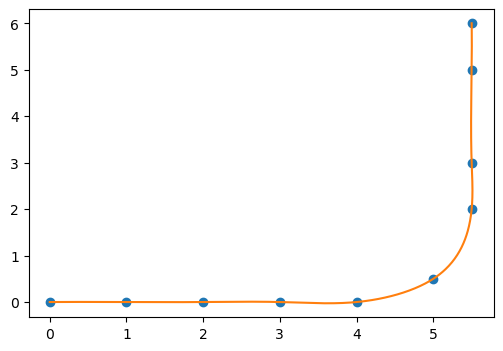

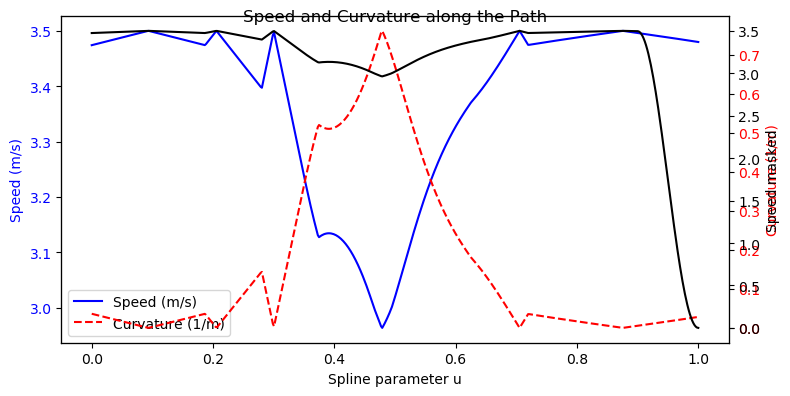

[3.47406569 3.47462045 3.47517534 3.47573036 3.47628548 3.47684071
 3.47739604 3.47795146 3.47850696 3.47906255 3.47961822 3.48017395
 3.48072975 3.48128561 3.48184153 3.4823975  3.48295352 3.48350959
 3.48406569 3.48462184 3.48517801 3.48573422 3.48629046 3.48684673
 3.48740302 3.48795933 3.48851566 3.48907201 3.48962837 3.49018475
 3.49074115 3.49129755 3.49185397 3.49241039 3.49296682 3.49352326
 3.4940797  3.49463616 3.49519261 3.49574907 3.49630553 3.496862
 3.49741846 3.49797493 3.4985314  3.49908788 3.49964435 3.49979918
 3.49924271 3.49868624 3.49812976 3.4975733  3.49701683 3.49646036
 3.4959039  3.49534744 3.49479098 3.49423453 3.49367808 3.49312164
 3.49256521 3.49200878 3.49145237 3.49089596 3.49033956 3.48978318
 3.48922681 3.48867046 3.48811412 3.4875578  3.48700151 3.48644523
 3.48588899 3.48533277 3.48477658 3.48422043 3.48366431 3.48310824
 3.48255221 3.48199622 3.48144029 3.48088441 3.48032859 3.47977284
 3.47921715 3.47866154 3.47810601 3.47755057 3.47699521 3.476439

In [37]:
import numpy as np
from scipy.interpolate import splprep, splev
import numpy as np
import matplotlib.pyplot as plt

x = np.array(x)
y = np.array(y)

# Parametric spline preparation (tck = knots, coefficients, degree)
tck, u = splprep([x, y], s=0)  # s=0 for interpolation through all points

# Evaluate the spline at 1000 evenly spaced points between 0 and 1
u_fine = np.linspace(0, 1, 500)
x_smooth, y_smooth = splev(u_fine, tck)

dx_dt, dy_dt = splev(u_fine, tck, der=1)
d2x_dt2, d2y_dt2 = splev(u_fine, tck, der=2)

# Compute curvature at each point
# Curvature formula: kappa = (x'y'' - y'x'') / (x'^2 + y'^2)^(3/2)
curvature = np.abs(dx_dt * d2y_dt2 - dy_dt * d2x_dt2) / (dx_dt**2 + dy_dt**2)**1.5

# Map curvature to approximate steering angle in degrees
# For simplicity, assume a proportional factor: steering_angle_deg = k * curvature
# This factor depends on wheelbase; here we choose k=180/π to get a rough angle in degrees
steering_angle_deg = np.degrees(curvature)  # crude approximation

angle_points = [0, 20, 40, 90]          # steering angles in degrees
speed_points = [3.5, 3.25, 3, 2.5]    # corresponding speeds in m/s
speeds = np.interp(steering_angle_deg, angle_points, speed_points)


# Apply velocity ramping at start and end
 # Use 15% of path for ramp-up and 15% for ramp-down

# Create velocity multiplier that goes 0->1->1->0
velocity_multiplier = np.ones_like(u_fine)

# Ramp up at the beginning (smooth using cosine)
# ramp_fraction = 0.15 
# ramp_up_mask = u_fine < ramp_fraction
# velocity_multiplier[ramp_up_mask] = 0.5 * (1 - np.cos(np.pi * u_fine[ramp_up_mask] / ramp_fraction))

ramp_fraction = 0.1
# Ramp down at the end (smooth using cosine)
ramp_down_mask = u_fine > (1 - ramp_fraction)
velocity_multiplier[ramp_down_mask] = 0.5 * (1 + np.cos(np.pi * (u_fine[ramp_down_mask] - (1 - ramp_fraction)) / ramp_fraction))

# Apply the multiplier to get final speeds
speeds_masked = speeds * velocity_multiplier

# Plot original points and the smooth spline
plt.figure(figsize=(6, 4))
plt.plot(x, y, 'o', label='Original points')
plt.plot(x_smooth, y_smooth, '-', label='Smooth spline')

import matplotlib.pyplot as plt

# --- Plot speed and curvature along the path ---
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot speed on the left y-axis
ax1.plot(u_fine, speeds, 'b-', label='Speed (m/s)')
ax1.set_xlabel('Spline parameter u')
ax1.set_ylabel('Speed (m/s)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a second y-axis for curvature
ax2 = ax1.twinx()
ax2.plot(u_fine, curvature, 'r--', label='Curvature (1/m)')
ax2.set_ylabel('Curvature (1/m)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax3 = ax1.twinx()
ax3.plot(u_fine, speeds_masked, 'black', label='Speed (m/s)')
ax3.set_ylabel('Speed masked', color='black')
ax3.tick_params(axis='y', labelcolor='black')

# Add a title and combined legend
fig.suptitle('Speed and Curvature along the Path')
fig.tight_layout()

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

plt.show()

print(speeds)


In [38]:
print(x_smooth.shape)
print(y_smooth.shape)
print(speeds_masked.shape)

(500,)
(500,)
(500,)


In [39]:
my_dict = {
    "x": x_smooth,
    "y": y_smooth,
    "speed":speeds_masked
}
np.savez("../tracks/blevel11.npz", **my_dict)

In [9]:
import math as ca



In [10]:
lf = 0.15875			# front tyres from center of gravity [m]
lr = 0.17145			# read tyres from center of gravity [m]
mass = 3.74 			# vehicle mass [kg]
Iz = 0.04712 			# moment of inertia [kgm^2]

p = [15.0, 15.0, 1.0, 1.0, 0.8, 0.8, 0.02, 0.001, 1.0, 0.05]
[-1.18283379e+01, 8.44133197e+00, -3.13430549e+00, 1.53994208e+00, 0.00000000e+00, 3.26238076e-01, 5.25505427e-03, 7.77642316e-02]
[-1.19038986e+01, 8.92304783e+00, -3.11663364e+00, 1.52242383e+00, -1.06785905e-02, 4.00329917e-01, -4.84997183e-01, 2.37764232e-01]
[-11.98117875, 9.40228659, -3.09298757, 1.48680442, -0.01992864, 0.55428524, -0.63623164, 0.39776423]
[-12.06018733, 9.87870879, -3.06122893, 1.44897618, -0.0364329, 0.7089282, -0.51780964, 0.4189]
[-12.14147115, 10.35216898, -3.02271471, 1.42140246, -0.06160558, 0.82595658, -0.19828905, 0.4189]
[-12.22599324, 10.82249848, -2.97905712, 1.41240511, -0.09298859, 0.91711507, 0.25768354, 0.4189]
[-12.31498457, 11.28944213, -2.93123241, 1.42714999, -0.12910757, 0.99421262, 0.7918575, 0.4189]
[-12.4098133, 11.75267232, -2.87973969, 1.46812999, -0.16941979, 1.0648714, 1.35421557, 0.4189]
[-12.5118703, 12.21180682, -2.82476705, 1.53559901, -0.21386682, 1.13409634, 1.90413766, 0.4189]
[-12.62247508, 12.66642565, -2.76629805, 1.62805282, -0.26260107, 1.20518069, 2.41090683, 0.4189]

[-12.62247508,
 12.66642565,
 -2.76629805,
 1.62805282,
 -0.26260107,
 1.20518069,
 2.41090683,
 0.4189]

In [37]:
# alphaf =  x[7] - ca.atan2(x[5] * lf + x[4], x[3])
# alphar =  ca.atan2(x[5] * lr - x[4], x[3])
# #arctan(omega * lr - vy, vx)



# Frx = mass * (x[6] * p[8]  -  p[9] * x[3]) - p[6] - p[7] * x[3] * x[3]
# Ffy = p[4] * ca.sin(p[2] * ca.atan(p[0] * alphaf))
# Fry = p[5] * ca.sin(p[3] * ca.atan(p[1] * alphar))

# dx0 = (x[3] * ca.cos(x[2])) - (x[4] * ca.sin(x[2])) #xdot
# dx1 = (x[3] * ca.sin(x[2])) + (x[4] * ca.cos(x[2])) #ydot
# dx2 = x[5] #phidot
# dx3 = (Frx - Ffy * ca.sin(x[7])) / mass + x[4] * x[5] #vxdot
# dx4 = (Fry + Ffy * ca.cos(x[7])) / mass - x[3] * x[5] #vydot
# dx5 = (lf * Ffy * ca.cos(x[7]) - lr * Fry) / Iz #omegadot

In [38]:
# print(alphaf, alphar, Frx, Ffy, Fry, dx0, dx1, dx2, dx3, dx4, dx5)

In [ ]:
# (x[5] * lf + x[4])/x[3]

0.04577881322817161